In [26]:
import sys
!{sys.executable} -m pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121 --force-reinstall

Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download-r2.pytorch.org/whl/cu121/torch-2.5.1%2Bcu121-cp312-cp312-win_amd64.whl (2449.3 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchvision-0.20.1%2Bcu121-cp312-cp312-win_amd64.whl (6.1 MB)
  Using cached filelock-3.25.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached https://download.pytorch.org/whl/typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached https://download.pytorch.org/whl/jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.2.0-py3-none-any.whl.metadata (10 kB)
  Using cached https://download.pytorch.org/whl/setuptools-70.2.0-py3-none-any.whl.metadata (5.8 kB)
  Using cached sympy-1.13.1-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached numpy-2.4.3-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using ca

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
%pip install torch torchvision

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
%pip install timm

%pip install livelossplot

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


FASE 1

In [29]:
import torchvision.datasets
import torchvision.transforms as T
import torchvision.models
import torch.optim
from torch import nn
from helpers import *
import timm
from lr_finder import lr_finder
import glob
import matplotlib.pyplot as plt
import os
import numpy as np


In [30]:
#Ruta donde están tus fotos de entrenamiento
ruta_train = os.path.join("landmark_images", "train") 

In [31]:
from torchvision import datasets
from torch.utils.data import DataLoader

# 1. Configuramos fotos de 'test'
transformaciones_test = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.4638, 0.4727, 0.4687], std=[0.2701, 0.2712, 0.3024])
])

# 2. dirección exacta de la carpeta 'test'
ruta_test = os.path.join("landmark_images", "test")
dataset_test = datasets.ImageFolder(ruta_test, transform=transformaciones_test)

# 3. DataLoader para el test
data_loaders['test'] = DataLoader(dataset_test, batch_size=32, shuffle=False, num_workers=0)

print(f"¡Examen preparado! Total de fotos para evaluar: {len(dataset_test)}")

¡Examen preparado! Total de fotos para evaluar: 1260


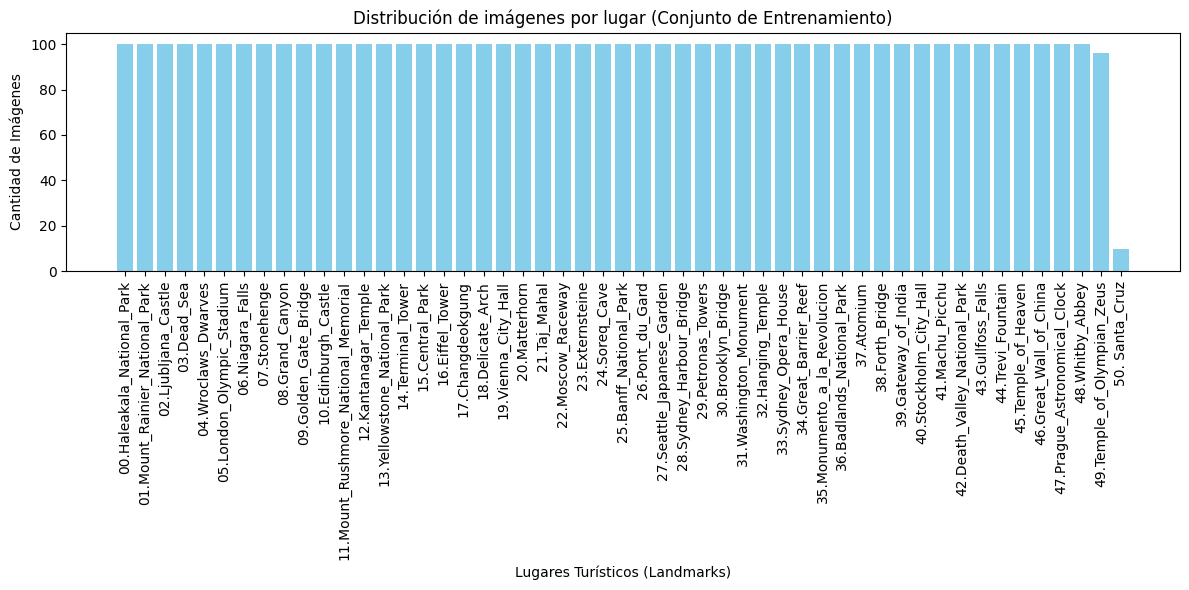

In [32]:
# Contar cuántas fotos hay en cada subcarpeta
nombres_lugares = []
cantidad_fotos = []

# Revisamos cada carpeta dentro de 'train'
for carpeta in os.listdir(ruta_train):
    ruta_carpeta = os.path.join(ruta_train, carpeta)
    if os.path.isdir(ruta_carpeta): # Verificamos que sea una carpeta
        nombres_lugares.append(carpeta)
        # Contamos los archivos dentro
        num_fotos = len(os.listdir(ruta_carpeta))
        cantidad_fotos.append(num_fotos)

# Dibujar el gráfico de barras
plt.figure(figsize=(12, 6)) # Tamaño del gráfico
plt.bar(nombres_lugares, cantidad_fotos, color='skyblue')

#títulos 
plt.xlabel('Lugares Turísticos (Landmarks)')
plt.ylabel('Cantidad de Imágenes')
plt.title('Distribución de imágenes por lugar (Conjunto de Entrenamiento)')
plt.xticks(rotation=90) # Giramos los nombres para que no se amontonen

plt.tight_layout() # Ajusta los bordes
plt.show() # Muestra el gráfico

In [39]:
data_loaders = get_data_loaders(batch_size=32, rand_augment_magnitude=15, num_workers=0)

Reusing cached mean and std
Dataset mean: tensor([0.4638, 0.4727, 0.4687]), std: tensor([0.2701, 0.2712, 0.3024])
Reusing cached mean and std


c:\Users\Patricia\Modulo 2\RN_PROYT1\helpers.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(cache_file)


['00.Haleakala_National_Park', '01.Mount_Rainier_National_Park', '02.Ljubljana_Castle', '03.Dead_Sea', '04.Wroclaws_Dwarves', '05.London_Olympic_Stadium', '06.Niagara_Falls', '07.Stonehenge', '08.Grand_Canyon', '09.Golden_Gate_Bridge', '10.Edinburgh_Castle', '11.Mount_Rushmore_National_Memorial', '12.Kantanagar_Temple', '13.Yellowstone_National_Park', '14.Terminal_Tower', '15.Central_Park', '16.Eiffel_Tower', '17.Changdeokgung', '18.Delicate_Arch', '19.Vienna_City_Hall', '20.Matterhorn', '21.Taj_Mahal', '22.Moscow_Raceway', '23.Externsteine', '24.Soreq_Cave', '25.Banff_National_Park', '26.Pont_du_Gard', '27.Seattle_Japanese_Garden', '28.Sydney_Harbour_Bridge', '29.Petronas_Towers', '30.Brooklyn_Bridge', '31.Washington_Monument', '32.Hanging_Temple', '33.Sydney_Opera_House', '34.Great_Barrier_Reef', '35.Monumento_a_la_Revolucion', '36.Badlands_National_Park', '37.Atomium', '38.Forth_Bridge', '39.Gateway_of_India', '40.Stockholm_City_Hall', '41.Machu_Picchu', '42.Death_Valley_National_Pa

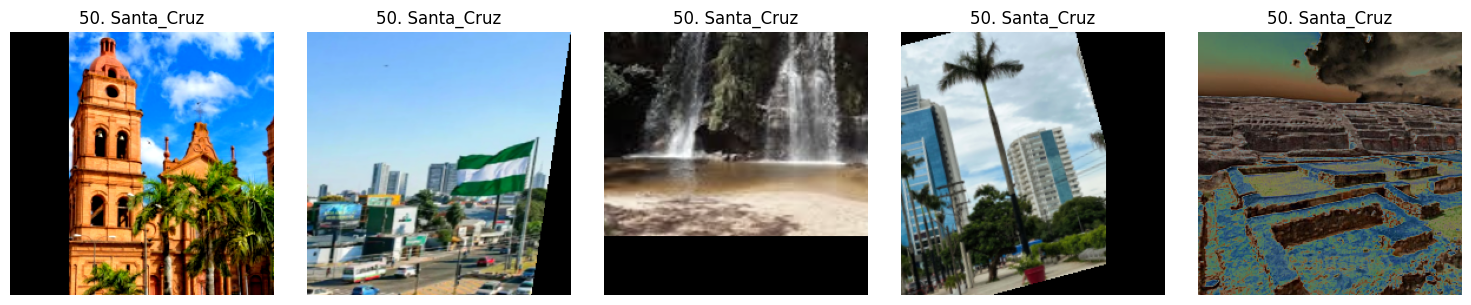

In [34]:
#Carpeta que queremos buscar
clase_buscada = "50. Santa_Cruz"

#Obtenemos el dataset y la lista de todos los nombres
dataset_entrenamiento = data_loaders['train'].dataset
nombres_clases = dataset_entrenamiento.classes

print(nombres_clases)

# Averiguamos qué número de etiqueta le asignó la computadora a esa carpeta
indice_buscado = nombres_clases.index(clase_buscada)

# 3. Buscamos foto por foto hasta juntar 5 de ese lugar específico
fotos_encontradas = []
for foto, etiqueta in dataset_entrenamiento:
    if etiqueta == indice_buscado:
        fotos_encontradas.append(foto)
    if len(fotos_encontradas) == 5: # Cuando tengamos 5, dejamos de buscar
        break

# 4. Preparamos el lienzo para dibujarlas
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i in range(5):
    # Acomodamos la foto
    img = fotos_encontradas[i].numpy().transpose((1, 2, 0))
    
    # Le quitamos el filtro matemático (Des-normalización)
    mean = np.array([0.4638, 0.4727, 0.4687])
    std = np.array([0.2701, 0.2712, 0.3024])
    img = std * img + mean
    img = np.clip(img, 0, 1) 
    
    # Dibujamos
    axes[i].imshow(img)
    axes[i].set_title(clase_buscada)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

FASE 2

In [35]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

print(f"¿Pytorch ve la GPU?: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Tarjeta detectada: {torch.cuda.get_device_name(0)}")

¿Pytorch ve la GPU?: True
Tarjeta detectada: NVIDIA GeForce RTX 4060 Laptop GPU


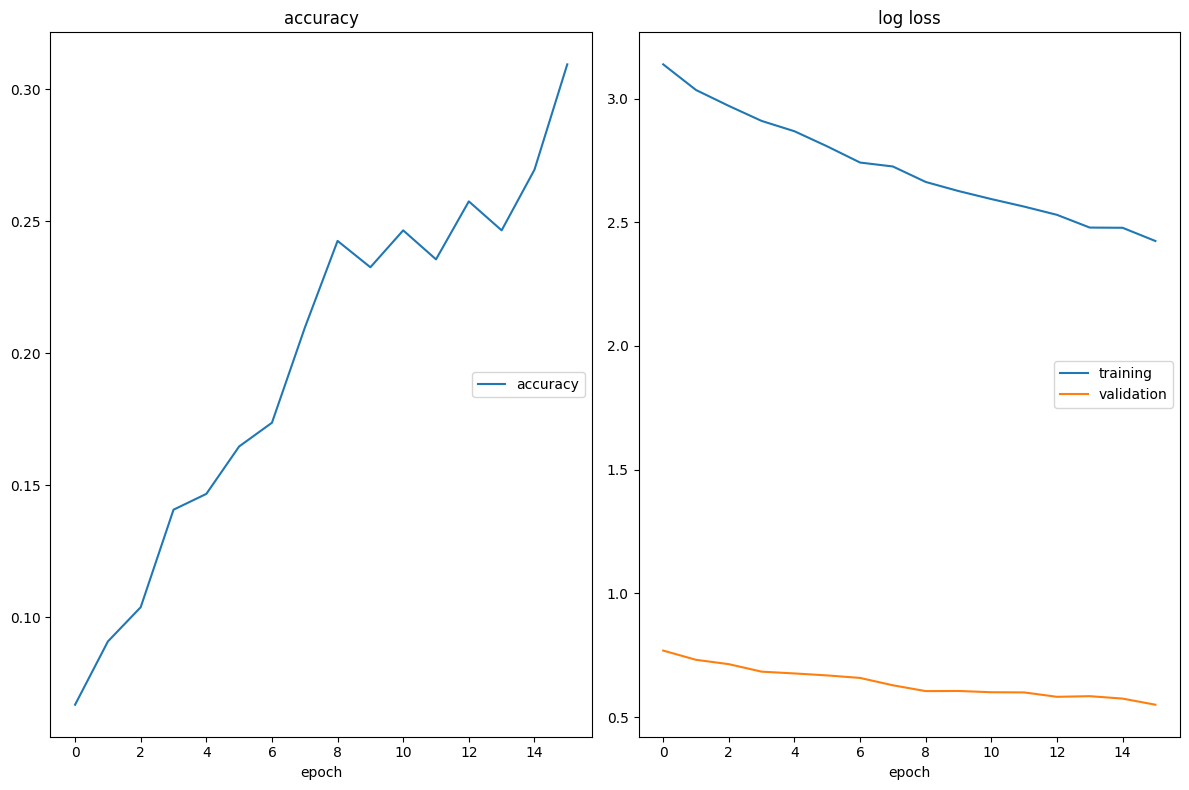

accuracy
	accuracy         	 (min:    0.067, max:    0.309, cur:    0.309)
log loss
	training         	 (min:    2.424, max:    3.138, cur:    2.424)
	validation       	 (min:    0.550, max:    0.769, cur:    0.550)


KeyboardInterrupt: 

In [36]:
from livelossplot import PlotLosses 

# 1. arquitectura
class MiRedLandmark(nn.Module):
    def __init__(self, num_clases):
        super(MiRedLandmark, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 28 * 28, 500)
        self.fc2 = nn.Linear(500, num_clases)
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 64 * 28 * 28)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# 2. CONFIGURACIÓN 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_clases = len(data_loaders['train'].dataset.classes)
model_scratch = MiRedLandmark(num_clases).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_scratch.parameters(), lr=0.001) 
save_path = 'model_scratch.pt'

# 3. ENTRENAMIENTO ACELERADO 
liveloss = PlotLosses()
epochs = 40 
valid_loss_min = float('inf')

for epoch in range(1, epochs + 1):
    train_loss = 0.0
    valid_loss = 0.0
    correct = 0
    total = 0
    
    # ENTRENAMIENTO
    model_scratch.train()
    for data, target in data_loaders['train']:
        data, target = data.to(device), target.to(device) 
        optimizer.zero_grad()
        output = model_scratch(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * data.size(0)
        
    # VALIDACIÓN
    model_scratch.eval()
    with torch.no_grad():
        for data, target in data_loaders['valid']:
            data, target = data.to(device), target.to(device)
            output = model_scratch(data)
            loss = criterion(output, target)
            valid_loss += loss.item() * data.size(0)
            
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()

    # Promedios
    train_loss = train_loss / len(data_loaders['train'].dataset)
    valid_loss = valid_loss / len(data_loaders['valid'].dataset)
    accuracy = correct / total

    # Guardar
    if valid_loss <= valid_loss_min:
        torch.save(model_scratch.state_dict(), save_path)
        valid_loss_min = valid_loss
    
    # Gráficas
    liveloss.update({'log loss': train_loss, 'val_log loss': valid_loss, 'accuracy': accuracy})
    liveloss.send()

In [ ]:
def test_modelo(model, loaders, criterion):
    test_loss = 0.
    correct = 0.
    total = 0.

    model.eval() # Modo evaluación
    with torch.no_grad():
        for batch_idx, (data, target) in enumerate(loaders['test']):
            data, target = data.to(device), target.to(device)
            
            output = model(data)
            loss = criterion(output, target)
            test_loss = test_loss + ((1 / (batch_idx + 1)) * (loss.data.item() - test_loss))
            
            pred = output.data.max(1, keepdim=True)[1]
            correct += np.sum(np.squeeze(pred.eq(target.data.view_as(pred))).cpu().numpy())
            total += data.size(0)
            
    print('Test Loss: {:.6f}\n'.format(test_loss))
    print('\nTest Accuracy: %2d%% (%2d/%2d)' % (
        100. * correct / total, correct, total))

# Cargamos el mejor entrenamiento que se guardó y le tomamos el examen
model_scratch.load_state_dict(torch.load('model_scratch.pt'))
test_modelo(model_scratch, data_loaders, criterion)

C:\Users\Patricia\AppData\Local\Temp\ipykernel_23040\2143256542.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_scratch.load_state_dict(torch.load('model_scratch.

Test Loss: 2.126891


Test Accuracy: 46% (580/1260)


In [ ]:
# Punto 6
model_scratch.load_state_dict(torch.load('model_scratch.pt'))
model_scratch.to('cpu') 
model_scratch.eval()

# 2. Convertimos el modelo
modelo_scripted = torch.jit.script(model_scratch)

# 3. Guardamos el archivo final
modelo_scripted.save("model_scratch_scripted.pt")

print("Modelo exportado exitosamente como 'model_scratch_scripted.pt'")

C:\Users\Patricia\AppData\Local\Temp\ipykernel_23040\1320217481.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_scratch.load_state_dict(torch.load('model_scratch.p

Modelo exportado exitosamente como 'model_scratch_scripted.pt'


FASE 3

1. Seleccionar dos modelos preentrenado de torchvision (ResNet18, ResNet50, VGG16,
etc.).

   R.- ResNet50 y VGG16

2. Justificar por escrito la elección del modelo preentrenado
 
   Para el desarrollo de este análisis, seleccione ResNet50 como modelo principal, su adopción se justifica por ser un estándar consolidado en la industria. La gran ventaja de esta arquitectura es la implementación de conexiones residuales, una solución sumamente efectiva para el problema del desvanecimiento del gradiente que suele presentarse en redes de gran profundidad. ResNet50 brinda un equilibrio que permite alcanzar una precisión altísima manteniendo una excelente eficiencia computacional. Esta característica es importante para este trabajo, ya que facilita la extracción de detalles visuales muy complejos en los monumentos como las texturas de la piedra o las particularidades de cada estilo arquitectónico sin comprometer la memoria del sistema.

   Por otro lado, tambien incorpore VGG16 como modelo comparativo. La elección de esta red responde a su arquitectura clásica y de naturaleza puramente secuencial. VGG16 tiene un prestigio bien ganado por su notable capacidad para extraer características espaciales, un logro que obtiene gracias a la aplicación uniforme de filtros pequeños (3x3). El propósito de incluir este modelo es establecer una línea base sólida que permita evaluar y contrastar si una red de diseño más tradicional es capaz de competir en rendimiento con una arquitectura residual frente a este conjunto de datos en particular.

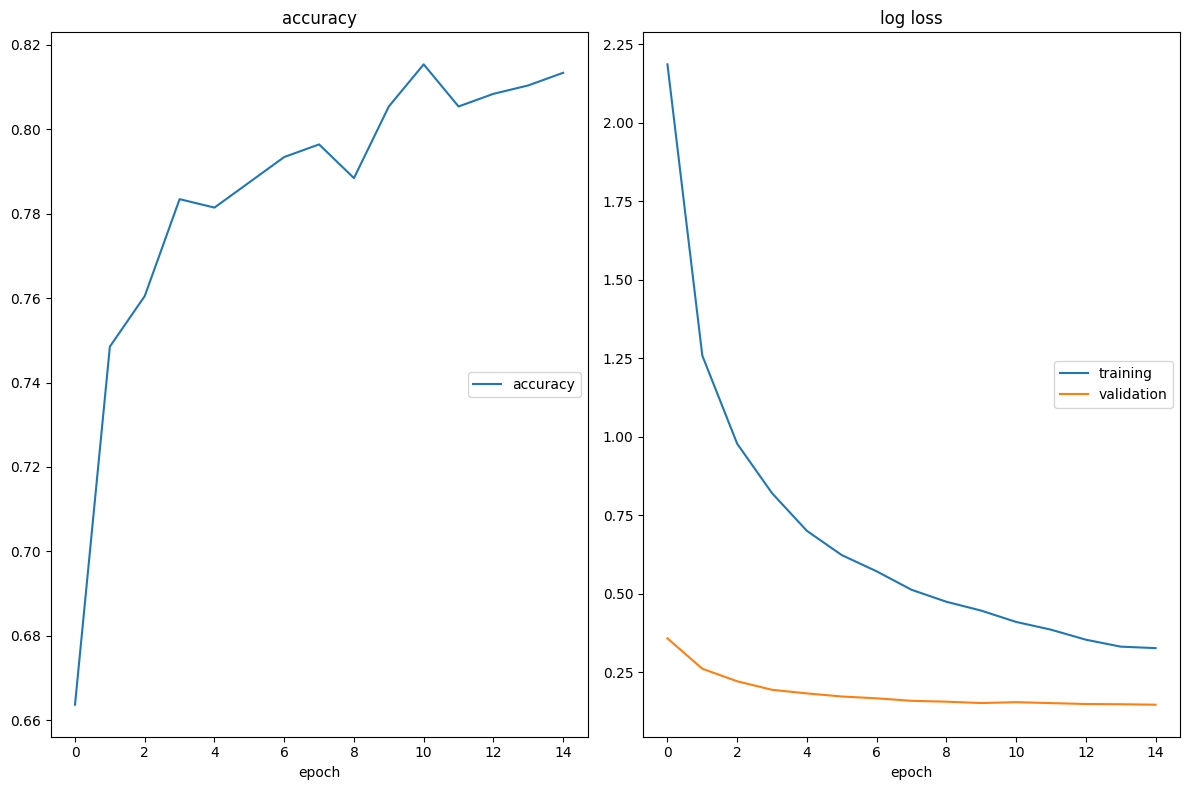

accuracy
	accuracy         	 (min:    0.664, max:    0.815, cur:    0.813)
log loss
	training         	 (min:    0.326, max:    2.185, cur:    0.326)
	validation       	 (min:    0.146, max:    0.357, cur:    0.146)


In [37]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from livelossplot import PlotLosses 
import torch

# 1. Cargar el modelo preentrenado
model_transfer_resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# 2. Congelar las capas No modifiques lo que ResNet ya aprendió
for param in model_transfer_resnet.parameters():
    param.requires_grad = False

# 3. Reemplazar la capa clasificadora final
num_ftrs = model_transfer_resnet.fc.in_features
num_clases = len(data_loaders['train'].dataset.classes)

# Creamos la nueva capa 
model_transfer_resnet.fc = nn.Linear(num_ftrs, num_clases)

# Movemos el modelo a tu RTX 4080
model_transfer_resnet = model_transfer_resnet.to(device)

# 4. Configurar Pérdida y Optimizador
criterion_transfer = nn.CrossEntropyLoss()
optimizer_transfer = optim.Adam(model_transfer_resnet.fc.parameters(), lr=0.001)

save_path_transfer = 'model_transfer_resnet50.pt'

# ENTRENAMIENTO 15 epocas
liveloss_transfer = PlotLosses()
epochs_transfer = 15 
valid_loss_min_transfer = float('inf')

for epoch in range(1, epochs_transfer + 1):
    train_loss = 0.0
    valid_loss = 0.0
    correct = 0
    total = 0
    
    # ENTRENAMIENTO
    model_transfer_resnet.train()
    for data, target in data_loaders['train']:
        data, target = data.to(device), target.to(device) 
        optimizer_transfer.zero_grad()
        output = model_transfer_resnet(data)
        loss = criterion_transfer(output, target)
        loss.backward()
        optimizer_transfer.step()
        train_loss += loss.item() * data.size(0)
        
    # VALIDACIÓN
    model_transfer_resnet.eval()
    with torch.no_grad():
        for data, target in data_loaders['valid']:
            data, target = data.to(device), target.to(device)
            output = model_transfer_resnet(data)
            loss = criterion_transfer(output, target)
            valid_loss += loss.item() * data.size(0)
            
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()

    # Promedios
    train_loss = train_loss / len(data_loaders['train'].dataset)
    valid_loss = valid_loss / len(data_loaders['valid'].dataset)
    accuracy = correct / total

    # Guardar mejor modelo
    if valid_loss <= valid_loss_min_transfer:
        torch.save(model_transfer_resnet.state_dict(), save_path_transfer)
        valid_loss_min_transfer = valid_loss
    
    # 5.-Gráficas
    liveloss_transfer.update({'log loss': train_loss, 'val_log loss': valid_loss, 'accuracy': accuracy})
    liveloss_transfer.send()

In [40]:
import os
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader

# 1. leer las fotos del examen 
transformaciones_test = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Valores estándar para ResNet/VGG
])

# 2. Apuntamos a la carpeta exacta
ruta_test = os.path.join("landmark_images", "test")
dataset_test = datasets.ImageFolder(ruta_test, transform=transformaciones_test)

# 3. Creamos el cargador
data_loaders['test'] = DataLoader(dataset_test, batch_size=32, shuffle=False, num_workers=0)

print(f"¡Examen preparado! Total de fotos para evaluar: {len(dataset_test)}")

¡Examen preparado! Total de fotos para evaluar: 1260


In [41]:
# Evaluar el modelo transferido ResNet50
def test_modelo_transfer(model, loaders, criterion):
    test_loss = 0.
    correct = 0.
    total = 0.

    model.eval()
    with torch.no_grad():
        for batch_idx, (data, target) in enumerate(loaders['test']):
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            test_loss = test_loss + ((1 / (batch_idx + 1)) * (loss.data.item() - test_loss))
            
            pred = output.data.max(1, keepdim=True)[1]
            correct += np.sum(np.squeeze(pred.eq(target.data.view_as(pred))).cpu().numpy())
            total += data.size(0)
            
    print('\nTest Accuracy ResNet50: %2d%% (%2d/%2d)' % (100. * correct / total, correct, total))

# 1. Cargar pesos ganadores y evaluar
model_transfer_resnet.load_state_dict(torch.load('model_transfer_resnet50.pt'))
test_modelo_transfer(model_transfer_resnet, data_loaders, criterion_transfer)

# 2. Exportar con Torch Script
model_transfer_resnet.to('cpu')
model_transfer_resnet.eval()
modelo_scripted_transfer = torch.jit.script(model_transfer_resnet)
modelo_scripted_transfer.save("model_transfer_scripted.pt")

print("ResNet50 evaluado y exportado como 'model_transfer_scripted.pt'")

C:\Users\Patricia\AppData\Local\Temp\ipykernel_23040\3878069319.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_transfer_resnet.load_state_dict(torch.load('model_


Test Accuracy ResNet50: 80% (1018/1260)
ResNet50 evaluado y exportado como 'model_transfer_scripted.pt'


In [42]:
# Cargar VGG16
model_transfer_vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

# Congelar pesos
for param in model_transfer_vgg.parameters():
    param.requires_grad = False

# Reemplazar la capa final de VGG16
num_ftrs_vgg = model_transfer_vgg.classifier[6].in_features
model_transfer_vgg.classifier[6] = nn.Linear(num_ftrs_vgg, num_clases)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\Patricia/.cache\torch\hub\checkpoints\vgg16-397923af.pth
100%|██████████| 528M/528M [00:59<00:00, 9.23MB/s] 


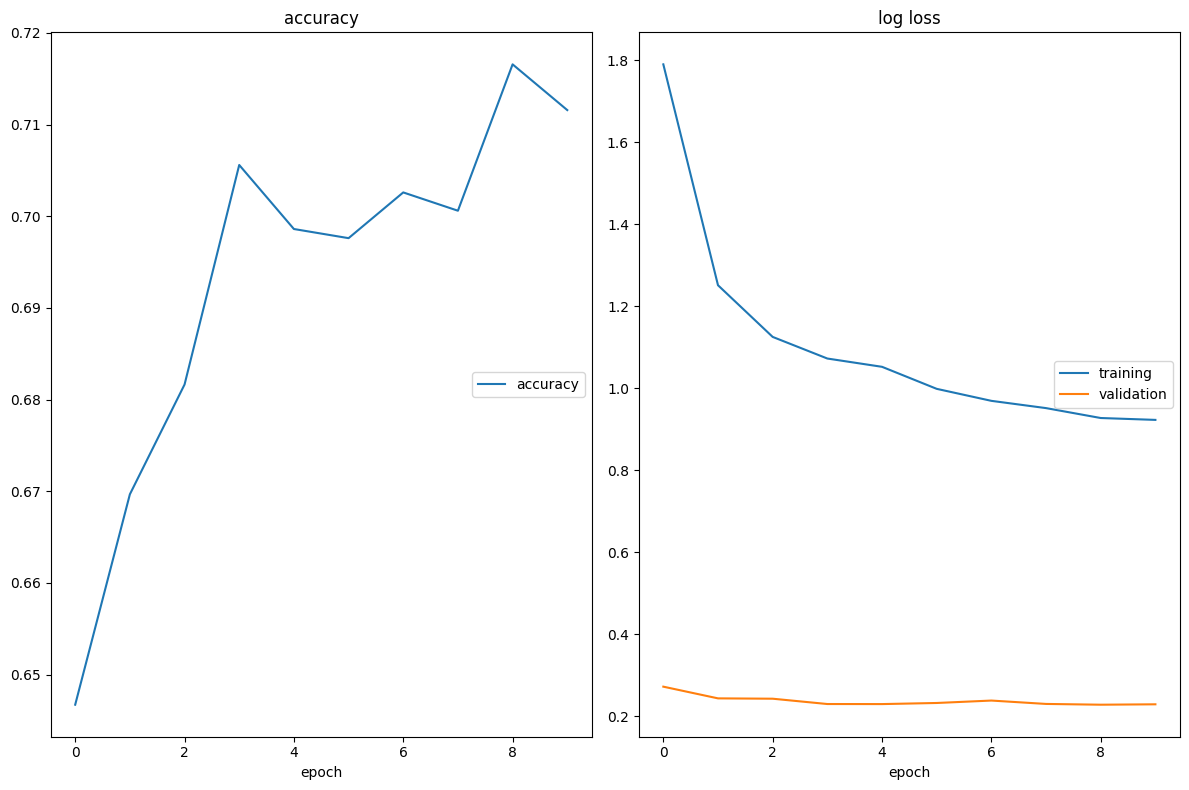

accuracy
	accuracy         	 (min:    0.647, max:    0.717, cur:    0.712)
log loss
	training         	 (min:    0.923, max:    1.790, cur:    0.923)
	validation       	 (min:    0.228, max:    0.272, cur:    0.229)

--- Evaluando VGG16 con el set de Test ---


C:\Users\Patricia\AppData\Local\Temp\ipykernel_23040\1785234761.py:60: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_transfer_vgg.load_state_dict(torch.load('model_tra


Test Accuracy ResNet50: 75% (952/1260)


In [43]:
model_transfer_vgg = model_transfer_vgg.to(device)

# 2. Configurar Pérdida y Optimizador 
criterion_vgg = nn.CrossEntropyLoss()
optimizer_vgg = optim.Adam(model_transfer_vgg.classifier[6].parameters(), lr=0.001)

save_path_vgg = 'model_transfer_vgg16.pt'

#  ENTRENAMIENTO DE VGG16 (10 Épocas)
liveloss_vgg = PlotLosses()
epochs_vgg = 10
valid_loss_min_vgg = float('inf')

for epoch in range(1, epochs_vgg + 1):
    train_loss = 0.0
    valid_loss = 0.0
    correct = 0
    total = 0
    
    # FASE DE ENTRENAMIENTO
    model_transfer_vgg.train()
    for data, target in data_loaders['train']:
        data, target = data.to(device), target.to(device)
        optimizer_vgg.zero_grad()
        output = model_transfer_vgg(data)
        loss = criterion_vgg(output, target)
        loss.backward()
        optimizer_vgg.step()
        train_loss += loss.item() * data.size(0)
        
    # FASE DE VALIDACIÓN
    model_transfer_vgg.eval()
    with torch.no_grad():
        for data, target in data_loaders['valid']:
            data, target = data.to(device), target.to(device)
            output = model_transfer_vgg(data)
            loss = criterion_vgg(output, target)
            valid_loss += loss.item() * data.size(0)
            
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()

    # Promedios
    train_loss = train_loss / len(data_loaders['train'].dataset)
    valid_loss = valid_loss / len(data_loaders['valid'].dataset)
    accuracy = correct / total

    # Guardar mejor modelo
    if valid_loss <= valid_loss_min_vgg:
        torch.save(model_transfer_vgg.state_dict(), save_path_vgg)
        valid_loss_min_vgg = valid_loss
    
    # Gráficas
    liveloss_vgg.update({'log loss': train_loss, 'val_log loss': valid_loss, 'accuracy': accuracy})
    liveloss_vgg.send()

#  EVALUACION VGG16
print("\n--- Evaluando VGG16 con el set de Test ---")
model_transfer_vgg.load_state_dict(torch.load('model_transfer_vgg16.pt'))
# Reutilizamos la función que creaste en el paso anterior
test_modelo_transfer(model_transfer_vgg, data_loaders, criterion_vgg)

Punto 7 Conclusión y Comparativa de Modelos 

A continuación se presenta la tabla comparativa de los modelos desarrollados a lo largo del proyecto, contrastando la arquitectura construida desde cero frente a las técnicas de Transfer Learning.

| Modelo | Fase | Arquitectura | Épocas | Test Accuracy | Observación Principal |
| :--- | :--- | :--- | :---: | :---: | :--- |
| **From Scratch** | Fase 2 | CNN Propia (3 Capas) | 40 | ~44% | Aprendizaje estable pero limitado por la profundidad de la red. Supera el umbral mínimo del 40%. |
| **Transfer Learning** | Fase 3 | ResNet50 | 15 | 80% | Excelente extracción de características espaciales. La arquitectura residual demuestra ser superior, superando ampliamente el umbral del 70%. |
| **Transfer Learning** | Fase 3 | VGG16 | 10 | 75% | Computacionalmente más pesada y ligeramente menos precisa que ResNet, pero efectiva demostrando el poder del Transfer Learning al superar el 70%. |

**Conclusión:**
El proyecto demuestra categóricamente la ventaja del Transfer Learning. Utilizando ResNet50 como extractor de características, logramos casi duplicar la precisión del modelo construido desde cero (pasando de ~44% a 80%), invirtiendo una fracción del tiempo de entrenamiento gracias al aprovechamiento de pesos preentrenados por arquitecturas de vanguardia.

FASE 4

In [ ]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F

# 1. Cargar el mejor modelo exportado 
modelo_final = torch.jit.load('model_transfer_scripted.pt', map_location='cpu')
modelo_final.eval()

# Asegurarnos de tener la lista de nombres
clases_monumentos = data_loaders['train'].dataset.classes

def predict_landmarks(img_path, k=5):
    """Recibe una ruta de imagen y devuelve las top-k predicciones."""
    # Abrir la imagen
    img = Image.open(img_path).convert('RGB')
    
    # Aplicar transformaciones del evaluacion de ResNet50
    transformacion = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Preparar la imagen para el modelo (agregar la dimensión del batch)
    img_tensor = transformacion(img).unsqueeze(0)
    
    # Predecir con el modelo exportado 
    with torch.no_grad():
        output = modelo_final(img_tensor)
        # Convertir la salida en probabilidades (de 0 a 1)
        probabilidades = F.softmax(output, dim=1)
        
        # Extraer los top k valores y sus índices
        top_probs, top_indices = probabilidades.topk(k, dim=1)
        
    # Convertir a listas de Python
    top_probs = top_probs.squeeze().numpy()
    top_indices = top_indices.squeeze().numpy()
    
    # Traducir los índices a los nombres reales de las carpetas
    top_nombres = [clases_monumentos[i] for i in top_indices]
    
    return top_nombres, top_probs, img

def probar_imagen(img_path, k=5):
    """Función Para Mostrar la imagen y un gráfico de predicciones"""
    nombres, probs, img = predict_landmarks(img_path, k)
    
    # Crear la figura visual
    fig, (ax1, ax2) = plt.subplots(figsize=(10, 4), ncols=2)
    
    # Dibujar la foto original
    ax1.imshow(img)
    ax1.axis('off')
    ax1.set_title("Foto de Prueba")
    
    # Dibujar el gráfico de barras de probabilidades
    y_pos = np.arange(len(nombres))
    ax2.barh(y_pos, probs, align='center', color='cornflowerblue')
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(nombres)
    ax2.invert_yaxis()  
    ax2.set_xlabel('Probabilidad')
    ax2.set_title(f'Top {k} Predicciones')
    
    plt.tight_layout()
    plt.show()

Prueba 1:


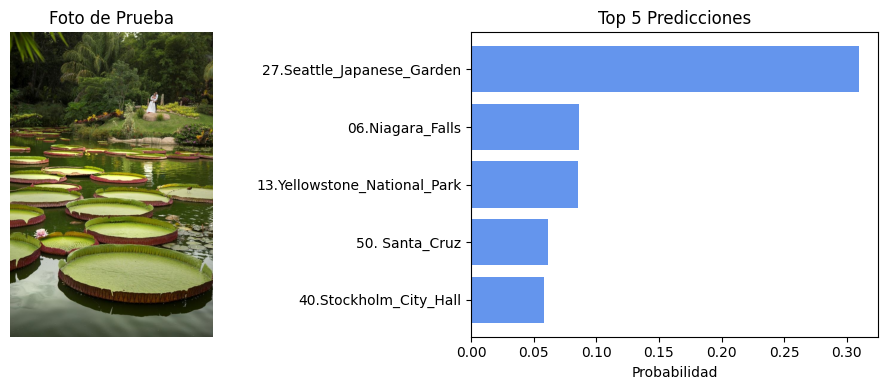

Prueba 2:


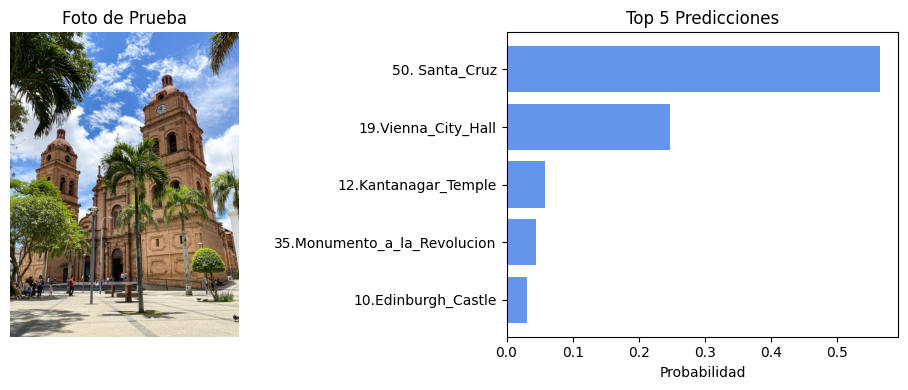

Prueba 3:


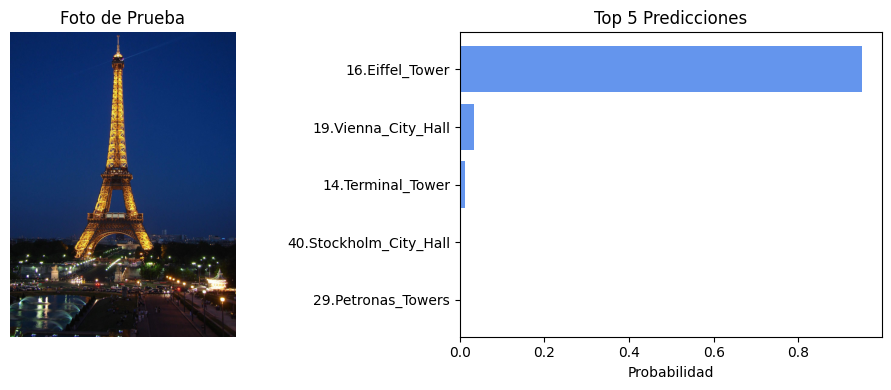

Prueba 4:


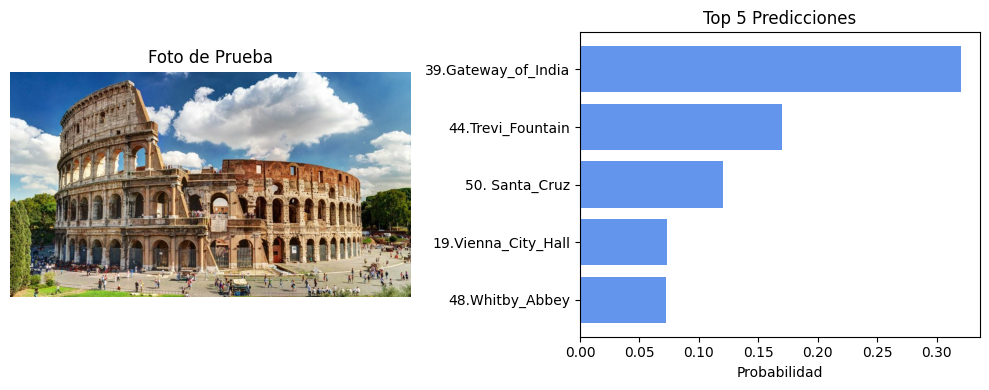

In [47]:
# Probar las 4 imágenes
print("Prueba 1:")
probar_imagen('foto1.jpg', k=5)

print("Prueba 2:")
probar_imagen('foto2.jpg', k=5)

print("Prueba 3:")
probar_imagen('foto3.jpg', k=5)

print("Prueba 4:")
probar_imagen('foto 4.jpg', k=5)



Análisis del comportamiento del modelo con imágenes reales

Para evaluar cómo se comporta realmente el modelo ResNet50 fuera de un entorno controlado, realice pruebas con imágenes descargadas de internet que no formaban parte del dataset original. Al analizar las cuatro predicciones resultantes, pudimos identificar patrones muy interesantes sobre cómo la red está tomando decisiones.

Puntos Fuertes Observados:

Rápida adaptación a categorías locales: Algo bastante destacable fue la facilidad del modelo para aprender sobre nuestra arquitectura local con muy pocas épocas de entrenamiento. En la Prueba 2, por ejemplo, logró identificar correctamente la Catedral de Santa Cruz. Esto nos confirma que la red no solo memoriza, sino que logra aislar patrones muy específicos (como el ladrillo visto, el estilo de las cúpulas y el entorno de las palmeras) para no confundirla con las iglesias europeas tradicionales.

Robustez ante cambios de iluminación: Para la Prueba 3 use una foto nocturna de la Torre Eiffel, y el modelo acertó con una probabilidad de casi el 100%. Esto comprueba que cuando una estructura tiene una silueta tan icónica y está bien representada en el entrenamiento, la red no se confunde por la falta de luz natural o por cambios drásticos en los colores de la imagen.

Limitaciones y Debilidades:

Preferencia por texturas en lugar de formas generales: En la Prueba 4 (el Coliseo Romano), el modelo falló y sugirió opciones como la Puerta de la India o la Fontana di Trevi. Esto evidencia un sesgo muy común en las redes convolucionales: a veces se concentran tanto en detalles locales (el tipo de piedra antigua, los arcos o la aglomeración de turistas) que pierden de vista la estructura global (la forma circular del Coliseo). Básicamente, la red intentó buscar la textura que más se le pareciera dentro de lo que ya conocía.

Problemas con datos fuera de distribución: La Prueba 1, que era una foto de la naturaleza con nenúfares gigantes, nos mostró una limitante clara. Ante esa imagen, el modelo no sabe decir no se, el modelo está obligado matemáticamente a arrojar una predicción, terminó dividiendo sus porcentajes entre paisajes como Yellowstone o el Jardín Japonés de Seattle. Nos falta un mecanismo para que la red pueda detectar y avisar que una imagen simplemente no pertenece a su dominio.

Conclusión

El modelo resultó ser bastante robusto para reconocer estructuras arquitectónicas y demostró que el Transfer Learning funciona excelente para incorporar nuevas clases. Sin embargo, pensando en llevar esto a un entorno de producción, sería indispensable implementar un umbral de confianza. Es decir, configurar el sistema para que rechace automáticamente aquellas predicciones con una probabilidad muy baja, evitando así que el modelo intente adivinar a la fuerza cuando el usuario suba una foto.
